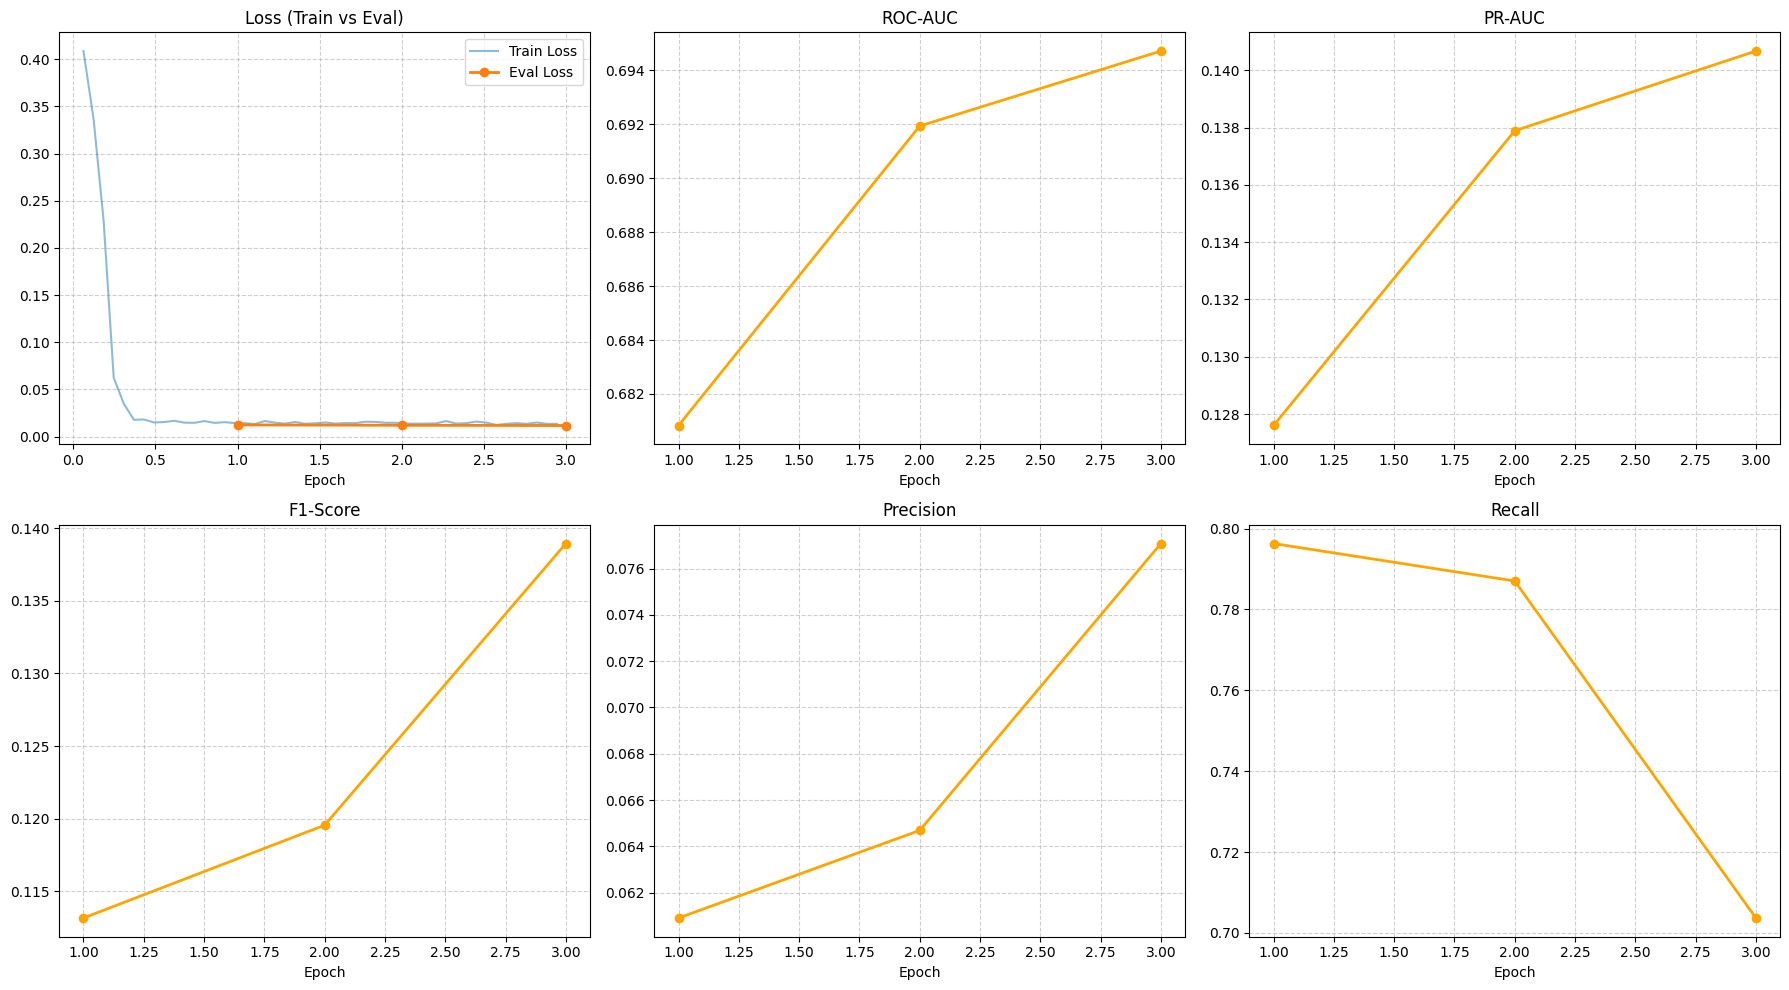

In [8]:
import pandas as pd
import json
import matplotlib.pyplot as plt

# Load the state
with open('data/checkpoints/experiments/focal_loss/checkpoint-489/trainer_state.json', 'r') as f:
    data = json.load(f)

# Convert log history to DataFrame
df = pd.DataFrame(data['log_history'])

# Separate training logs (contain 'loss') and evaluation logs (contain 'eval_loss')
train_df = df[df['loss'].notna()]
eval_df = df[df['eval_loss'].notna()]

# Define the metrics we want to track from the eval steps
metrics = [
    ('eval_loss', 'Loss (Train vs Eval)'),
    ('eval_auc_roc', 'ROC-AUC'),
    ('eval_auc_pr', 'PR-AUC'),
    ('eval_f1', 'F1-Score'),
    ('eval_precision', 'Precision'),
    ('eval_recall', 'Recall')
]

# Create a figure with a grid of subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (col, title) in enumerate(metrics):
    ax = axes[i]

    # Special case for Loss to show both training and evaluation
    if col == 'eval_loss':
        ax.plot(train_df['epoch'], train_df['loss'],
                label='Train Loss', alpha=0.5)
        ax.plot(eval_df['epoch'], eval_df[col],
                label='Eval Loss', marker='o', linewidth=2)
        ax.legend()
    else:
        # Plot other eval metrics
        ax.plot(eval_df['epoch'], eval_df[col],
                marker='o', color='orange', linewidth=2)

    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()